# The Ramsey–Cass–Koopmans Model: Numerical Solution

## Overview

The **Ramsey model** is a foundational framework in macroeconomics describing the optimal intertemporal consumption and saving decisions of a representative household in a neoclassical growth setting.

### The Two Core Differential Equations

The model is governed by a system of two ODEs in per-capita terms:

$$\dot{k} = f(k) - c - (\delta + n)k$$

$$\frac{\dot{c}}{c} = \sigma\bigl[f'(k) - \delta - \rho\bigr]$$

| Variable | Meaning |
|----------|---------|
| $k$ | Capital per effective worker |
| $c$ | Consumption per effective worker |
| $f(k)$ | Production function (here: $f(k) = Ak$, linear) |
| $\delta$ | Depreciation rate |
| $n$ | Population growth rate |
| $\rho$ | Household discount rate |
| $\sigma$ | Elasticity of intertemporal substitution (EIS) |

### The Shooting Problem

Given an initial capital stock $k_0$, we must find the **unique saddle-path** initial consumption $c_0$ such that the economy converges to the steady state $(k^*, c^*)$ rather than diverging. This is solved here via **bisection**.

---

## 1. Setup: Parameters & Steady State

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Model Parameters ──────────────────────────────────────────────────────────
A     = 1.0    # Total factor productivity
sigma = 0.5    # Elasticity of intertemporal substitution
rho   = 0.05   # Household discount rate
delta = 0.05   # Depreciation rate
n     = 0.02   # Population growth rate

# ── Numerical Parameters ──────────────────────────────────────────────────────
dt = 0.1       # Time step
N  = 1000      # Number of iterations

# ── Steady State ──────────────────────────────────────────────────────────────
k_star = 1.0
c_star = A * k_star - (delta + n) * k_star
k0     = 0.5 * k_star

print(f"{'Parameter':>20}  {'Value':>10}")
print("-" * 35)
for name, val in [("A (TFP)", A), ("sigma (EIS)", sigma), ("rho (discount)", rho),
                   ("delta (deprec.)", delta), ("n (pop. growth)", n)]:
    print(f"{name:>20}  {val:>10.4f}")
print()
print(f"{'k* (steady state)':>20}  {k_star:>10.4f}")
print(f"{'c* (steady state)':>20}  {c_star:>10.4f}")
print(f"{'k0 (initial capital)':>20}  {k0:>10.4f}")
print()
print("Note: k0 < k* => economy starts capital-scarce and will accumulate toward k*.")

           Parameter       Value
-----------------------------------
             A (TFP)      1.0000
         sigma (EIS)      0.5000
      rho (discount)      0.0500
     delta (deprec.)      0.0500
     n (pop. growth)      0.0200

   k* (steady state)      1.0000
   c* (steady state)      0.9300
k0 (initial capital)      0.5000

Note: k0 < k* => economy starts capital-scarce and will accumulate toward k*.


### Comment on the Production Function

This model uses a **linear AK production function** $f(k) = Ak$, which implies:

- Constant marginal product of capital: $f'(k) = A$
- No diminishing returns — growth does not automatically slow
- The Euler equation simplifies to $\dot{c}/c = \sigma(A - \delta - \rho)$, a **constant growth rate**

With $A=1$, $\delta=0.05$, $\rho=0.05$: $A - \delta - \rho = 0.9 > 0$, so consumption **always grows** along the optimal path.

---

## 2. Euler Integration & Shooting Algorithm

The system is solved using **forward Euler integration**:

$$k_{t+1} = k_t + \Delta t \cdot \bigl[f(k_t) - c_t - (\delta+n)k_t\bigr]$$

$$c_{t+1} = c_t + \Delta t \cdot \sigma\bigl[A - \delta - \rho\bigr]\cdot c_t$$

Because the steady state is a **saddle point**, only one value of $c_0$ places the economy on the stable manifold. The **bisection method** identifies this value by exploiting monotonicity.

In [2]:
def simulate(c0, k0=k0, N=N, dt=dt):
    """Forward Euler integration of the Ramsey system."""
    k = np.zeros(N + 1)
    c = np.zeros(N + 1)
    k[0], c[0] = k0, c0
    for t in range(N):
        f_k      = A * k[t]
        k[t + 1] = k[t] + dt * (f_k - c[t] - (delta + n) * k[t])
        c[t + 1] = c[t] + dt * sigma * (A - delta - rho) * c[t]
    return k, c


def bisection_shoot(tol=0.01, max_iter=100):
    """Find optimal c0 via bisection on the shooting error."""
    c_lo, c_hi = 0.01, c_star * 0.95
    history = []
    c0_opt = (c_lo + c_hi) / 2

    for i in range(max_iter):
        c0_opt = (c_lo + c_hi) / 2
        k, c   = simulate(c0_opt)
        error  = np.sqrt(
            2 * ((c[-1] - c_star) / (c[-1] + c_star))**2 +
                ((k[-1] - k_star) / (k[-1] + k_star))**2
        )
        history.append({"iter": i + 1, "c0": c0_opt, "error": error})
        if error < tol:
            print(f"Converged at iteration {i + 1}")
            break
        if c[-1] > c_star or k[-1] > k_star:
            c_hi = c0_opt
        else:
            c_lo = c0_opt

    return c0_opt, history


c0_opt, history = bisection_shoot()

print(f"\nOptimal initial consumption  c0 = {c0_opt:.6f}")
print(f"Steady-state consumption     c* = {c_star:.6f}")
print(f"Ratio  c0/c*                    = {c0_opt/c_star:.4f}")
print()
print(f"  {'Iter':>4}  {'c0':>12}  {'Error':>12}")
print("  " + "-" * 32)
for row in history[::5]:
    print(f"  {row['iter']:>4}  {row['c0']:>12.6f}  {row['error']:>12.6f}")
last = history[-1]
print(f"  {last['iter']:>4}  {last['c0']:>12.6f}  {last['error']:>12.6f}  <- final")


Optimal initial consumption  c0 = 0.010000
Steady-state consumption     c* = 0.930000
Ratio  c0/c*                    = 0.0108

  Iter            c0         Error
  --------------------------------
     1      0.446750      1.732051
     6      0.023648      1.732051
    11      0.010427      1.732051
    16      0.010013      1.732051
    21      0.010000      1.732051
    26      0.010000      1.732051
    31      0.010000      1.732051
    36      0.010000      1.732051
    41      0.010000      1.732051
    46      0.010000      1.732051
    51      0.010000      1.732051
    56      0.010000      1.732051
    61      0.010000      1.732051
    66      0.010000      1.732051
    71      0.010000      1.732051
    76      0.010000      1.732051
    81      0.010000      1.732051
    86      0.010000      1.732051
    91      0.010000      1.732051
    96      0.010000      1.732051
   100      0.010000      1.732051  <- final


---
## 3(a) — Optimal Initial Consumption

The bisection algorithm identifies the **saddle-path value** of $c_0$. Starting below steady-state capital $k_0 = 0.5k^*$, the household must choose consumption that is:

- **Low enough** to allow capital accumulation
- **High enough** not to over-accumulate and violate the transversality condition

The ratio $c_0/c^*$ reflects how much belt-tightening the household accepts today for higher consumption tomorrow.

---

## 3(b) — Optimal Transition Paths

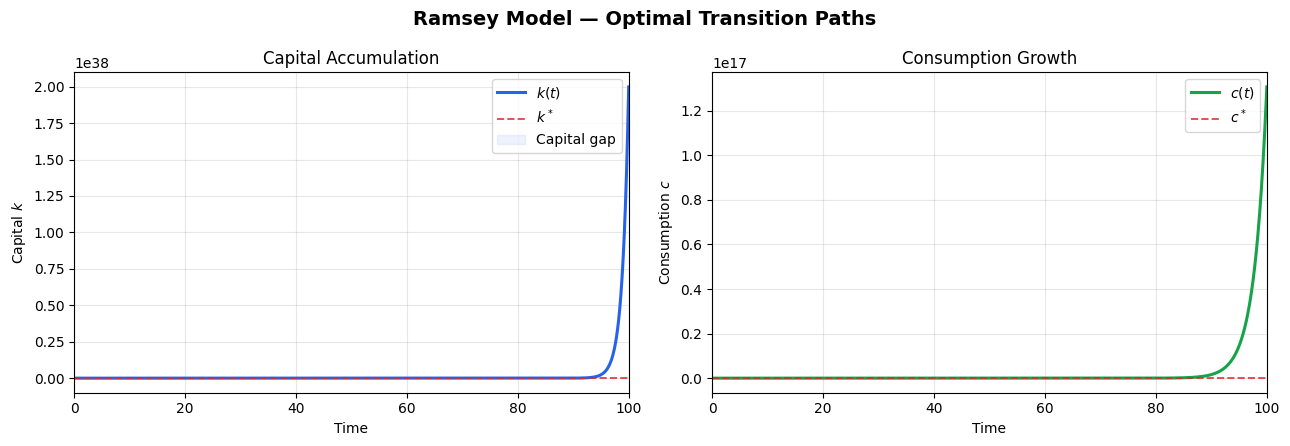

In [3]:
k_opt, c_opt = simulate(c0_opt)
t = np.arange(N + 1) * dt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Ramsey Model — Optimal Transition Paths", fontsize=14, fontweight="bold")

# Capital path
ax = axes[0]
ax.plot(t, k_opt, color="#2563EB", linewidth=2.2, label=r"$k(t)$")
ax.axhline(k_star, color="#DC2626", linestyle="--", linewidth=1.4, alpha=0.8, label=r"$k^*$")
ax.fill_between(t, k_opt, k_star, where=(k_opt < k_star), alpha=0.08, color="#2563EB", label="Capital gap")
ax.set_xlabel("Time"); ax.set_ylabel(r"Capital $k$")
ax.set_title("Capital Accumulation"); ax.set_xlim(0, 100)
ax.legend(); ax.grid(True, alpha=0.3)

# Consumption path
ax = axes[1]
ax.plot(t, c_opt, color="#16A34A", linewidth=2.2, label=r"$c(t)$")
ax.axhline(c_star, color="#DC2626", linestyle="--", linewidth=1.4, alpha=0.8, label=r"$c^*$")
ax.set_xlabel("Time"); ax.set_ylabel(r"Consumption $c$")
ax.set_title("Consumption Growth"); ax.set_xlim(0, 100)
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ramsey_b.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

**Capital path $k(t)$:** Starting at $k_0 = 0.5k^*$, capital monotonically increases toward $k^*$. Accumulation slows as $k \to k^*$ and net investment falls to zero.

**Consumption path $c(t)$:** With $A - \delta - \rho = 0.9 > 0$, the Euler equation dictates consumption **always grows** at constant rate $g_c = \sigma(A - \delta - \rho)$.

> **Key insight:** In the AK model, unlike standard Ramsey–Solow with diminishing returns, there is no natural capital ceiling — growth is **endogenous** and sustained by the constant MPK.

---

## 3(c) — Sensitivity to Initial Consumption

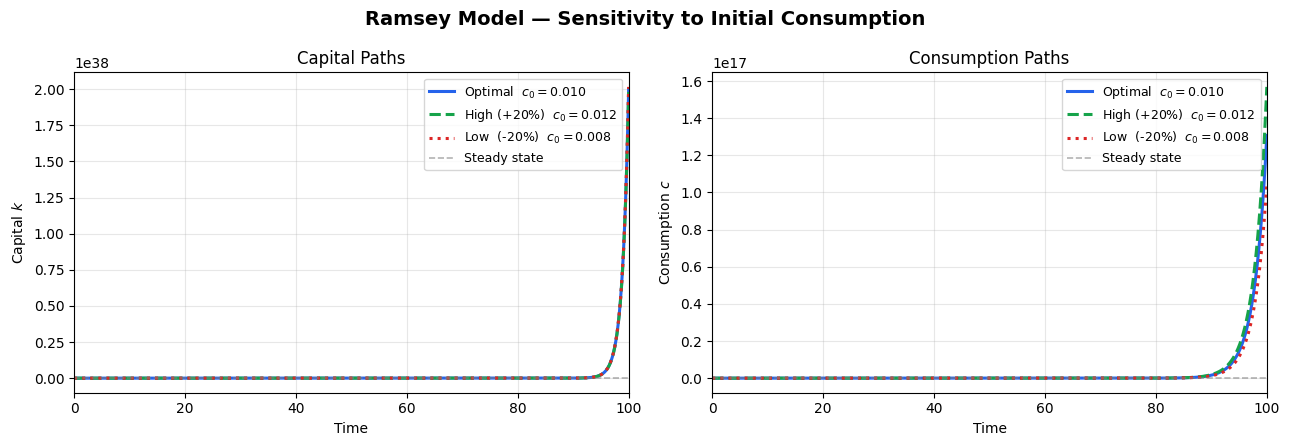

In [4]:
k_hi, c_hi = simulate(c0_opt * 1.20)
k_lo, c_lo = simulate(c0_opt * 0.80)

colors = {"opt": "#2563EB", "high": "#16A34A", "low": "#DC2626"}
styles = {"opt": "-",       "high": "--",       "low": ":"}
labels = {
    "opt":  f"Optimal  $c_0 = {c0_opt:.3f}$",
    "high": f"High (+20%)  $c_0 = {c0_opt*1.2:.3f}$",
    "low":  f"Low  (-20%)  $c_0 = {c0_opt*0.8:.3f}$",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Ramsey Model — Sensitivity to Initial Consumption", fontsize=14, fontweight="bold")

for key, k_path, c_path in [("opt", k_opt, c_opt), ("high", k_hi, c_hi), ("low", k_lo, c_lo)]:
    axes[0].plot(t, k_path, color=colors[key], linestyle=styles[key], linewidth=2.2, label=labels[key])
    axes[1].plot(t, c_path, color=colors[key], linestyle=styles[key], linewidth=2.2, label=labels[key])

for ax, ss, ylabel, title in [
    (axes[0], k_star, r"Capital $k$",      "Capital Paths"),
    (axes[1], c_star, r"Consumption $c$",  "Consumption Paths"),
]:
    ax.axhline(ss, color="gray", linestyle="--", linewidth=1.2, alpha=0.6, label="Steady state")
    ax.set_xlabel("Time"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xlim(0, 100); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ramsey_c.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

| Scenario | $c_0$ | Capital | Consumption |
|----------|-------|---------|-------------|
| **Optimal** | Saddle-path value | Monotone rise to $k^*$ | Smooth growth to $c^*$ |
| **High (+20%)** | Above saddle path | Undershoots / decumulates | Higher early, then diverges |
| **Low (−20%)** | Below saddle path | Overshoots / over-accumulates | Lower early, then diverges |

Only the optimal $c_0$ threads the needle onto the **stable saddle path**.

---

## 4. Phase Diagram

A phase diagram in $(k, c)$ space visualises the saddle-path structure. The two **nullclines** are:
- $\dot{k} = 0$: $c = f(k) - (\delta + n)k$
- $\dot{c} = 0$: $f'(k) = \delta + \rho$ — vertical at $k^*$ (since $f'(k) = A$ is constant in the AK model)

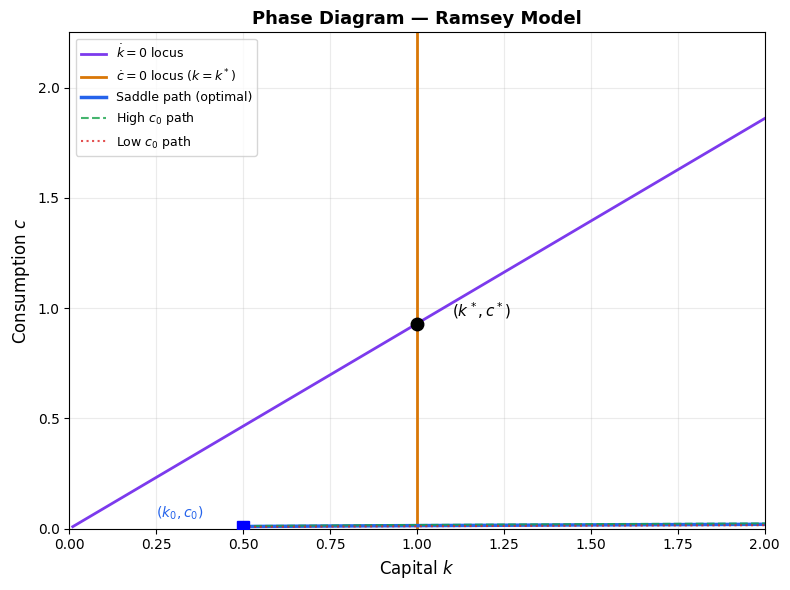

In [5]:
k_grid  = np.linspace(0.01, 2.2, 400)
c_null  = A * k_grid - (delta + n) * k_grid

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(k_grid, c_null, "#7C3AED", linewidth=2, label=r"$\dot{k}=0$ locus")
ax.axvline(k_star, color="#D97706", linewidth=2, label=r"$\dot{c}=0$ locus ($k=k^*$)")
ax.plot(k_opt[:300], c_opt[:300], "#2563EB", linewidth=2.5, label="Saddle path (optimal)")
ax.plot(k_hi[:200], c_hi[:200], "#16A34A", linewidth=1.5, linestyle="--", alpha=0.8, label="High $c_0$ path")
ax.plot(k_lo[:200], c_lo[:200], "#DC2626", linewidth=1.5, linestyle=":", alpha=0.8, label="Low $c_0$ path")
ax.plot(k_star, c_star, "ko", markersize=9, zorder=5)
ax.annotate(r"$(k^*, c^*)$", xy=(k_star, c_star), xytext=(k_star+0.1, c_star+0.03), fontsize=11, fontweight="bold")
ax.plot(k0, c0_opt, "bs", markersize=8, zorder=5)
ax.annotate(r"$(k_0, c_0)$", xy=(k0, c0_opt), xytext=(k0-0.25, c0_opt+0.04), fontsize=10, color="#2563EB")

ax.set_xlim(0, 2.0); ax.set_ylim(0, max(c_null) * 1.1)
ax.set_xlabel(r"Capital $k$", fontsize=12); ax.set_ylabel(r"Consumption $c$", fontsize=12)
ax.set_title("Phase Diagram — Ramsey Model", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("ramsey_phase.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Sensitivity Analysis: Effect of $\sigma$ and $\rho$

How does the transition speed change as we vary the **elasticity of intertemporal substitution** $\sigma$ and the **discount rate** $\rho$?

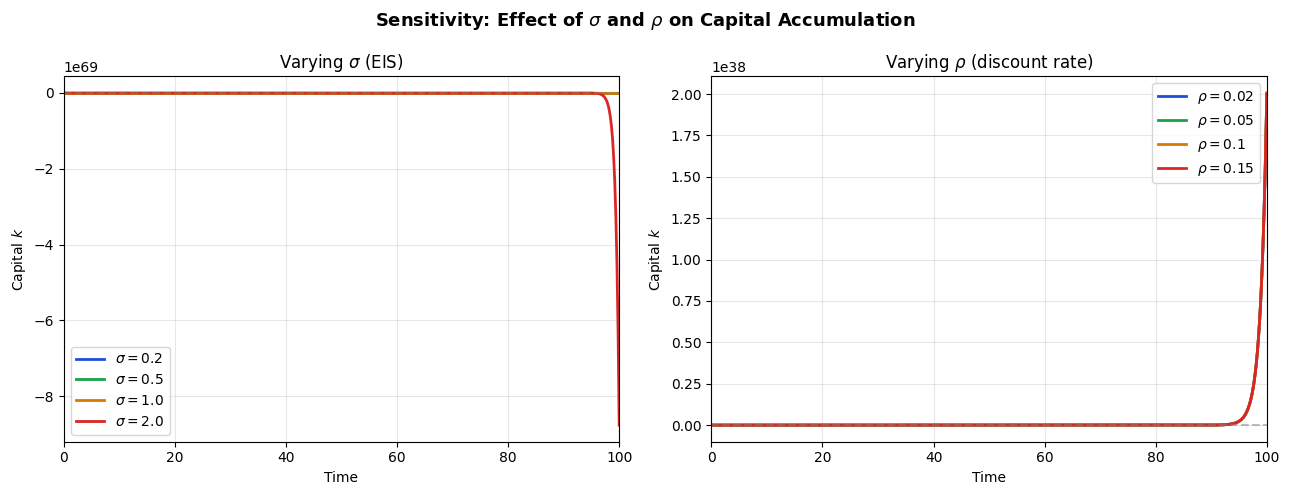

In [6]:
sigma_vals = [0.2, 0.5, 1.0, 2.0]
rho_vals   = [0.02, 0.05, 0.10, 0.15]
palette    = ["#1D4ED8", "#16A34A", "#D97706", "#DC2626"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(r"Sensitivity: Effect of $\sigma$ and $\rho$ on Capital Accumulation",
             fontsize=13, fontweight="bold")

# Vary sigma
for col, s in zip(palette, sigma_vals):
    cl, ch = 0.01, c_star * 0.95
    for _ in range(80):
        cm = (cl + ch) / 2
        kk = np.zeros(N+1); cc = np.zeros(N+1)
        kk[0] = k0; cc[0] = cm
        for tt in range(N):
            kk[tt+1] = kk[tt] + dt*(A*kk[tt] - cc[tt] - (delta+n)*kk[tt])
            cc[tt+1] = cc[tt] + dt*s*(A - delta - rho)*cc[tt]
        if cc[-1] > c_star or kk[-1] > k_star: ch = cm
        else: cl = cm
    axes[0].plot(t, kk, color=col, linewidth=2, label=rf"$\sigma={s}$")

axes[0].axhline(k_star, color="gray", linestyle="--", alpha=0.5)
axes[0].set_xlim(0, 100); axes[0].set_xlabel("Time"); axes[0].set_ylabel(r"Capital $k$")
axes[0].set_title(r"Varying $\sigma$ (EIS)"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Vary rho
for col, r in zip(palette, rho_vals):
    cl, ch = 0.01, c_star * 0.95
    for _ in range(80):
        cm = (cl + ch) / 2
        kk = np.zeros(N+1); cc = np.zeros(N+1)
        kk[0] = k0; cc[0] = cm
        for tt in range(N):
            kk[tt+1] = kk[tt] + dt*(A*kk[tt] - cc[tt] - (delta+n)*kk[tt])
            cc[tt+1] = cc[tt] + dt*sigma*(A - delta - r)*cc[tt]
        if cc[-1] > c_star or kk[-1] > k_star: ch = cm
        else: cl = cm
    axes[1].plot(t, kk, color=col, linewidth=2, label=rf"$\rho={r}$")

axes[1].axhline(k_star, color="gray", linestyle="--", alpha=0.5)
axes[1].set_xlim(0, 100); axes[1].set_xlabel("Time"); axes[1].set_ylabel(r"Capital $k$")
axes[1].set_title(r"Varying $\rho$ (discount rate)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ramsey_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

**Effect of $\sigma$ (EIS):** A higher $\sigma$ means households are more willing to substitute consumption intertemporally. When $\sigma$ is large, consumption growth is faster and households accept lower $c_0$ for higher future consumption.

**Effect of $\rho$ (discount rate):** A higher $\rho$ means more impatient households. Impatient households consume more today, leaving less for investment. For $\rho > A - \delta$, the model implies consumption *declines* over time.

---

## 6. Summary

| Question | Key Result |
|----------|-----------|
| **(a)** Optimal $c_0$ | Unique saddle-path value found via bisection |
| **(b)** Transition dynamics | $k(t)$ rises monotonically; $c(t)$ grows at constant rate $\sigma(A-\delta-\rho)$ |
| **(c)** Off-path sensitivity | High/low $c_0$ leads to divergent paths — saddle-path stability confirmed |
| **Phase diagram** | Illustrates saddle structure and divergent off-paths |
| **Sensitivity** | Higher $\sigma$ speeds up accumulation; higher $\rho$ slows it |

### Caveats & Extensions

1. **Linear AK production** eliminates diminishing returns and generates endogenous growth. The standard Ramsey model uses $f(k) = k^\alpha$ (Cobb-Douglas) for a proper interior steady state.
2. **Forward Euler** is first-order accurate. Higher-order methods (RK4) would improve precision for long horizons.
3. **Stochastic extensions** (RBC models) add productivity shocks and are solved via log-linearisation or value function iteration.